# PTT版上的科技業求職與職涯討論分析

第 18 組：M144020003 莊雅筑、M144020005 胡新容、M144020009 劉芊妤、M144020018 陳孝杰

影片連結：https://youtu.be/Lg0gFQZsG5w

## A. 動機和分析目的
科技業是現今求職的熱門領域之一，不論是台灣企業或是外商都吸引了眾多求職者關注。  
由於PTT板上也有許多相關討論，因此我們希望透過分析PTT上的討論來分析台灣科技業求職者最關心的職涯議題。

本專案將透過情緒分析、主題分析、社群網路分析來探討不同科技公司在PTT論壇上的品牌聲量與形象：
1. 情緒分析：觀察各公司在 PTT 上的評價偏正面還是負面
2. 主題分析：分析各公司在 PTT 上常被討論的主題
3. 社群網路分析：觀察各公司與職場議題間的關係

## B. 資料來源
使用 TarFlow 蒐集 PTT Tech_Job 討論版上的文章
- 關鍵字：台積電、TSMC、聯發科、MTK、聯詠、瑞昱、Realtek、群聯、Phison、鴻海、廣達、緯創、仁寶、華碩、和碩、友達、日月光、世界先進、美光、Micron、Google、NVIDIA、AMD、ASML
- 時間： 2025/06-2026/06
- 資料筆數：約 690 篇文章
- 欄位說明：  
包含以下 11 個欄位：
+ `system_id`: 系統編號
+ `artUrl`：文章網址
+ `artTitle`：文章標題
+ `artDate`：文章日期
+ `artPoster`：發文者
+ `artCatagory`：文章類別
+ `artContent`：文章內容
+ `artComment`：文章評論
+ `e_ip`：發文或推文者的 IP 位址
+ `insertedDate`：插入日期
+ `dataSource`：資料來源



## C. 分析資料(包括文字資料和社會網絡資料)

大綱：
1. 資料前處理
2. 情緒分析：觀察各公司在 PTT 上的評價偏正面還是負面
3. 主題分析：分析各公司在 PTT 上常被討論的主題
4. 社群網路分析：觀察各公司與職場議題間的關係

# 以主題模型分析 PTT Tech_Job 科技公司品牌聲量與職場形象

資料：`sna2026s_2_12bbceacc3_4.csv`  

本 notebook 的分析主軸：

1. 公司聲量分析：哪些公司被討論最多。
2. 主題模型分析：科技公司文章中常見的職場／產業議題。
3. 公司 × 主題分析：不同公司常被連結到哪些議題。
4. 公司類型比較：半導體製造、IC 設計、系統廠、外商／設備商的主題差異。

## 0. 套件安裝

如果本機或 Colab 尚未安裝下列套件，先取消註解並執行這一格。若已安裝，可略過。

說明：安裝本 notebook 需要的文字分析、主題模型與視覺化套件；已安裝時可略過。


In [ ]:
# !pip install pandas numpy matplotlib jieba scikit-learn gensim pyLDAvis
# !pip install bertopic sentence_transformers hdbscan
# !pip install git+https://github.com/Text-Analytics-and-Retrieval/GuidedLDA.git#egg=GuidedLDA

## 0.1 Colab 路徑與模型快取設定

如果不是在 Colab 執行，可以略過這一格。

說明：設定 Colab 工作目錄與模型快取位置，方便讀取 final_proj 內的資料與字型。


In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/01_NSYSU/02_2026-spring/SMA/project1/final_proj') # 請將這行修改為自己的 google drive 路徑
os.listdir() # 確認目錄內容

# 指定模型 cache 位置
cache_dir = "/content/drive/MyDrive/01_NSYSU/02_2026-spring/SMA/project1/sma_final/model_cache"
os.makedirs(cache_dir, exist_ok=True)

# Hugging Face 主要 cache 位置
os.environ["HF_HOME"] = cache_dir
os.environ["HF_HUB_CACHE"] = os.path.join(cache_dir, "hub")

# 給 sentence-transformers / BERTopic 用
os.environ["SENTENCE_TRANSFORMERS_HOME"] = os.path.join(cache_dir, "sentence_transformers")

# 給舊版 transformers 用，可加可不加
os.environ["TRANSFORMERS_CACHE"] = os.path.join(cache_dir, "transformers")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. 套件

說明：載入資料處理、文字清理、斷詞、主題模型與圖表繪製所需套件。


In [ ]:
import os
import re
import time
from collections import Counter, OrderedDict
from pprint import pprint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from gensim.corpora import Dictionary
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus
from matplotlib.font_manager import fontManager

import pyLDAvis

說明：關閉部分套件警告，讓 notebook 輸出更容易閱讀。


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", DeprecationWarning)

說明：設定 gensim 等套件的執行訊息格式。


In [ ]:
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

說明：指定 Taipei Sans TC Beta，避免中文圖表出現亂碼。


In [ ]:
# 設定中文字體
fontManager.addfont('./TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta'] #使圖中中文能正常顯示
plt.rcParams['axes.unicode_minus'] = False #使負號能夠顯示
plt.rcParams['font.size'] = '14'

## 2. 讀入資料與研究設定

這份資料集是以科技公司關鍵字篩選過的 PTT Tech_Job 文章。因此後續分析不只看「哪些公司最多」，而是比較每家公司常出現在什麼職場／產業議題脈絡。

說明：讀入 PTT Tech_Job 公司關鍵字文章資料，並先查看前幾筆內容。


In [ ]:
ptt_raw = pd.read_csv('./sna2026s_2_12bbceacc3_4.csv')  # 匯資料
ptt_raw.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/Tech_Job/M.1750216576.A...,[新聞]AI裁員潮來了？亞馬遜CEO警告未來數年,2025-06-18 11:16:14,baddaddy,Tech_Job,原文標題：\nAI 裁員潮來了？亞馬遜 CEO 警告未來數年人力將減少\n\n日期來源：\n...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""xvited945"", ...",49.216.161.54,2025-06-19 01:37:44,ptt
1,2,https://www.ptt.cc/bbs/Tech_Job/M.1750223764.A...,[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,2025-06-18 13:16:02,Dalapa,Tech_Job,"鴻海A事業群-印度班加羅爾\n招募軟體工程師一位\n大學畢業三年工作經驗,多益550分\n碩...","[{""cmtStatus"": ""→"", ""cmtPoster"": ""Leohs"", ""cmt...",42.76.131.192,2025-06-19 01:37:44,ptt
2,3,https://www.ptt.cc/bbs/Tech_Job/M.1750227747.A...,Re:[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,2025-06-18 14:22:25,secret99,Tech_Job,前陣子有大陸獵頭找SCM總監\n師12級\n開出的薪水是台幣350萬元,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""owen5566"", ""...",49.218.141.46,2025-06-19 01:37:44,ptt


說明：確認資料筆數與欄位名稱，了解後續可使用的欄位。


In [ ]:
ptt_raw.shape, ptt_raw.columns

((686, 11),
 Index(['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster',
        'artCatagory', 'artContent', 'artComment', 'e_ip', 'insertedDate',
        'dataSource'],
       dtype='object'))

### 2.1 公司關鍵字與公司類型

公司關鍵字依照爬蟲篩選詞設定，並補上常見英文名稱、PTT 暱稱或別名，方便做公司聲量與公司 × 主題比較。

說明：建立公司名稱、英文名稱與常見別名的對照表，作為公司標記依據。


In [ ]:
company_keywords = {
    '台積電': ['台積電', '台積', 'TSMC', 'GG'],
    '聯發科': ['聯發科', 'MTK', '發哥'],
    '聯詠': ['聯詠'],
    '瑞昱': ['瑞昱', 'Realtek'],
    '群聯': ['群聯', 'Phison'],
    '鴻海': ['鴻海', 'Foxconn', '富士康'],
    '廣達': ['廣達', 'Quanta'],
    '緯創': ['緯創'],
    '仁寶': ['仁寶'],
    '華碩': ['華碩', 'ASUS'],
    '和碩': ['和碩'],
    '友達': ['友達', 'AUO'],
    '日月光': ['日月光', 'ASE'],
    '世界先進': ['世界先進', 'VIS'],
    '美光': ['美光', 'Micron'],
    'Google': ['Google'],
    'NVIDIA': ['NVIDIA', '輝達'],
    'AMD': ['AMD'],
    'ASML': ['ASML'],
}

company_group_map = {
    '台積電': '半導體製造/封測',
    '世界先進': '半導體製造/封測',
    '日月光': '半導體製造/封測',
    '聯發科': 'IC設計',
    '聯詠': 'IC設計',
    '瑞昱': 'IC設計',
    '群聯': 'IC設計',
    'AMD': 'IC設計',
    'NVIDIA': 'IC設計',
    '鴻海': '系統廠/代工廠',
    '廣達': '系統廠/代工廠',
    '緯創': '系統廠/代工廠',
    '仁寶': '系統廠/代工廠',
    '華碩': '系統廠/代工廠',
    '和碩': '系統廠/代工廠',
    '友達': '系統廠/代工廠',
    'Google': '外商/設備商',
    '美光': '外商/設備商',
    'ASML': '外商/設備商',
}

說明：定義清理與公司比對函數，避免網址或 PTT 簽名檔造成公司誤標。


In [ ]:
def strip_ptt_noise_for_matching(text):
    text = '' if pd.isna(text) else str(text)
    text = re.sub(r'(http|https)://\S+', ' ', text)
    text = re.sub(r'(?is)\n\s*-\s*\n.*$', ' ', text)  # 移除 PTT 簽名檔，避免 Google Pixel 等誤判
    text = re.sub(r'(?im)^sent from .+$', ' ', text)
    text = re.sub(r'(?im)^--\s*$', ' ', text)
    return text


def keyword_in_text(text, keyword):
    text = strip_ptt_noise_for_matching(text)
    if re.search(r'[A-Za-z0-9]', keyword):
        pattern = r'(?<![A-Za-z0-9])' + re.escape(keyword) + r'(?![A-Za-z0-9])'
        return re.search(pattern, text, flags=re.IGNORECASE) is not None
    return keyword in text


def find_companies(text):
    matched = []
    for company, keywords in company_keywords.items():
        if any(keyword_in_text(text, kw) for kw in keywords):
            matched.append(company)
    return matched

### 2.2 職場／產業議題 seed words

說明：設定 GuidedLDA 使用的五個職場/產業議題與 seed words。


In [ ]:
issue_topic_keywords = OrderedDict({
    '薪資與財務表現': ['薪水', '薪資', '年薪', '分紅', '獎金', '加薪', '調薪', 'package', 'bonus', '待遇', '股票', '萬元', '億元', '月薪', '營收', '獲利', '平均', '中位數'],
    '組織管理與員工議題': ['工時', '加班', '輪班', '值班', '責任制', '壓力', 'WLB', '下班', '生活', '爆肝', '裁員', '員工', '人力', '組織', '管理', '機密', '調查', '違規', '要求'],
    '求職面試與職涯': ['offer', '面試', '請益', '錄取', '履歷', '面試官', '職缺', '徵才', '面試流程', '選擇', '轉職', '跳槽', '升遷', '年資', '新人', '職涯', '離職', '工作', '主管', '經驗'],
    '產業技術與職務': ['製程', '設備', 'IC設計', '韌體', '軟體', 'PM', 'FAE', '演算法', '研發', '工程師', '製造', '先進製程', '先進封裝', '廠務', '工安', '事故', '廠區', '安全'],
    '國際產業新聞': ['晶片', '半導體', 'AI', '人工智慧', '美國', '中國', '輝達', '英特爾', '投資', '關稅', '出口管制', '供應鏈', '產能', '擴廠', '市場', '全球', '韓國'],
})

issue_topic_names = list(issue_topic_keywords.keys())

## 3. 前處理與公司標記

先用原始標題與內文標記公司，避免英文字如 `TSMC`、`NVIDIA`、`ASML` 在中文清理時被刪掉。主題建模時再另外清理文字。

說明：建立分析用資料表，合併標題與內文，並標記每篇文章提到的公司。


In [ ]:
ptt = ptt_raw.copy()
ptt['doc_id'] = ptt.index
ptt['artTitle'] = ptt['artTitle'].fillna('').astype(str)
ptt['artContent'] = ptt['artContent'].fillna('').astype(str)
ptt['artDate'] = pd.to_datetime(ptt['artDate'])
ptt['raw_text'] = ptt['artTitle'] + ' ' + ptt['artContent']
ptt['analysis_text'] = ptt['artTitle'] + ' ' + ptt['artContent'].apply(strip_ptt_noise_for_matching)
ptt['companies'] = ptt['analysis_text'].apply(find_companies)

company_df = ptt[ptt['companies'].map(len) > 0].copy()
company_df[['artTitle', 'artDate', 'companies']].head(10)

,artTitle,artDate,companies
1,[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,2025-06-18 13:16:02,[鴻海]
2,Re:[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,2025-06-18 14:22:25,[鴻海]
3,[新聞]台積電擴廠外移和供電不穩有關？國科會認了：有影響,2025-06-18 18:19:38,[台積電]
4,[新聞]蔣尚義：遺憾沒打敗英特爾，台積電未來10,2025-06-18 19:39:01,"[台積電, 鴻海]"
5,[新聞]亞馬遜執行長賈西開第一槍示警AI導致,2025-06-19 08:51:24,[廣達]
6,[討論]南部是不是把主要產業全部押寶上台積了,2025-06-19 14:00:51,"[台積電, 聯發科, 群聯, 鴻海]"
7,[新聞]台積電攔胡GoogleTensorG5代工三星難接受,2025-06-19 19:51:24,"[台積電, 聯發科, Google]"
8,[請益]PIP違規在TSMC會很嚴重嗎？,2025-06-20 18:39:34,[台積電]
9,[新聞]美國科技顧問：中國晶片設計僅落後美國2年,2025-06-20 20:05:43,"[NVIDIA, AMD]"
10,[新聞]彭博：軟銀孫正義尋求與台積電在美建兆,2025-06-20 21:05:11,"[台積電, NVIDIA]"


說明：統計原始文章數、成功標記公司文章數與未標記文章數。


In [ ]:
print('原始文章數：', len(ptt))
print('有標記到公司的文章數：', len(company_df))
print('沒有標記到公司的文章數：', len(ptt) - len(company_df))

原始文章數： 686
有標記到公司的文章數： 666
沒有標記到公司的文章數： 20


#### 結果解讀：資料篩選
本資料共 686 篇文章，其中 666 篇可對應到至少一個公司關鍵字，表示原始爬蟲資料大多確實與目標科技公司相關。未標記到公司的 20 篇可能是簽名檔、轉錄內容或內文未直接出現公司名稱，後續主題分析以有公司標記的文章為主。

說明：將一篇文章中的多家公司展開成多列，方便計算公司聲量。


In [ ]:
company_exploded = company_df.explode('companies').rename(columns={'companies': 'company'}).copy()
company_exploded['company_group'] = company_exploded['company'].map(company_group_map)
company_exploded[['artTitle', 'company', 'company_group']].head(10)

,artTitle,company,company_group
1,[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,鴻海,系統廠/代工廠
2,Re:[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,鴻海,系統廠/代工廠
3,[新聞]台積電擴廠外移和供電不穩有關？國科會認了：有影響,台積電,半導體製造/封測
4,[新聞]蔣尚義：遺憾沒打敗英特爾，台積電未來10,台積電,半導體製造/封測
4,[新聞]蔣尚義：遺憾沒打敗英特爾，台積電未來10,鴻海,系統廠/代工廠
5,[新聞]亞馬遜執行長賈西開第一槍示警AI導致,廣達,系統廠/代工廠
6,[討論]南部是不是把主要產業全部押寶上台積了,台積電,半導體製造/封測
6,[討論]南部是不是把主要產業全部押寶上台積了,聯發科,IC設計
6,[討論]南部是不是把主要產業全部押寶上台積了,群聯,IC設計
6,[討論]南部是不是把主要產業全部押寶上台積了,鴻海,系統廠/代工廠


## 4. 公司聲量分析

同一篇文章如果提到多家公司，會在 `company_exploded` 中展開，分別計入各家公司。

說明：計算各公司被提到的文章數，作為公司品牌聲量指標。


In [ ]:
company_voice = (
    company_exploded.groupby(['company', 'company_group'])
    .size()
    .reset_index(name='article_count')
    .sort_values('article_count', ascending=False)
)
company_voice

,company,company_group,article_count
7,台積電,半導體製造/封測,422
3,NVIDIA,IC設計,163
2,Google,外商/設備商,94
15,聯發科,IC設計,56
0,AMD,IC設計,43
13,美光,外商/設備商,38
18,鴻海,系統廠/代工廠,36
1,ASML,外商/設備商,23
9,廣達,系統廠/代工廠,23
10,日月光,半導體製造/封測,20


說明：繪製公司聲量排行榜，觀察哪些公司討論量最高。


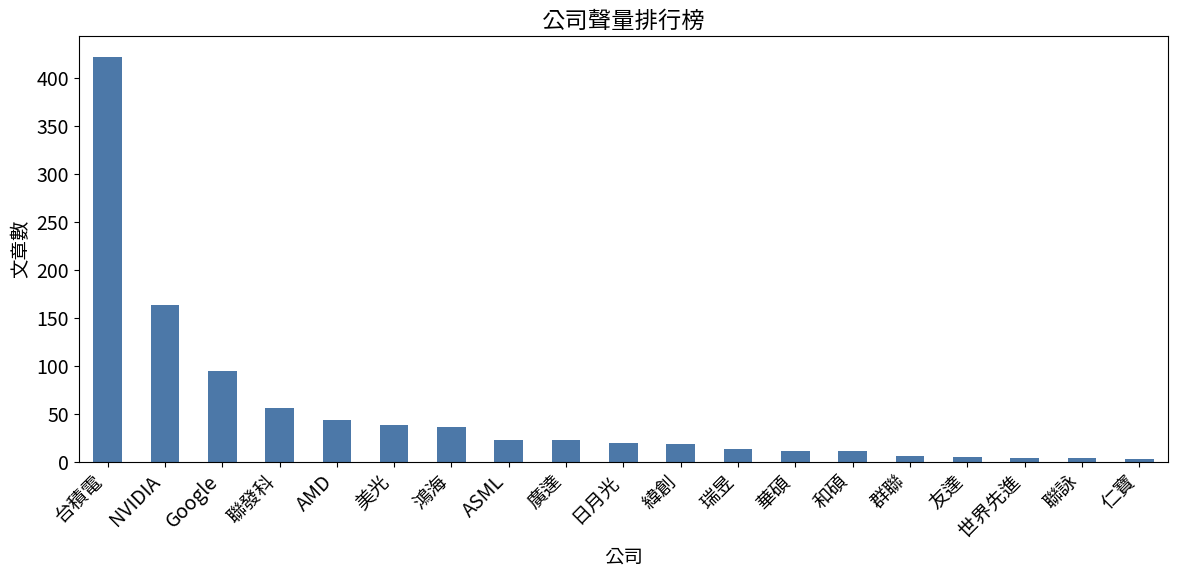

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
company_voice.plot.bar(x='company', y='article_count', ax=ax, color='#4C78A8', legend=False)
ax.set_title('公司聲量排行榜')
ax.set_xlabel('公司')
ax.set_ylabel('文章數')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

說明：依公司類型彙整聲量，比較半導體、IC 設計、系統廠與外商的討論量。


In [ ]:
group_voice = (
    company_exploded.groupby('company_group')
    .size()
    .reset_index(name='article_count')
    .sort_values('article_count', ascending=False)
)
group_voice

,company_group,article_count
1,半導體製造/封測,446
0,IC設計,285
2,外商/設備商,155
3,系統廠/代工廠,107


#### 結果解讀：公司聲量
公司聲量高度集中在台積電，其次是 NVIDIA、Google、聯發科、AMD。若以公司類型來看，半導體製造/封測與 IC 設計的討論量最高，顯示 Tech_Job 近期公司討論主要圍繞半導體與 AI 相關供應鏈。

說明：繪製公司類型聲量圖，呈現不同產業類型的討論差異。


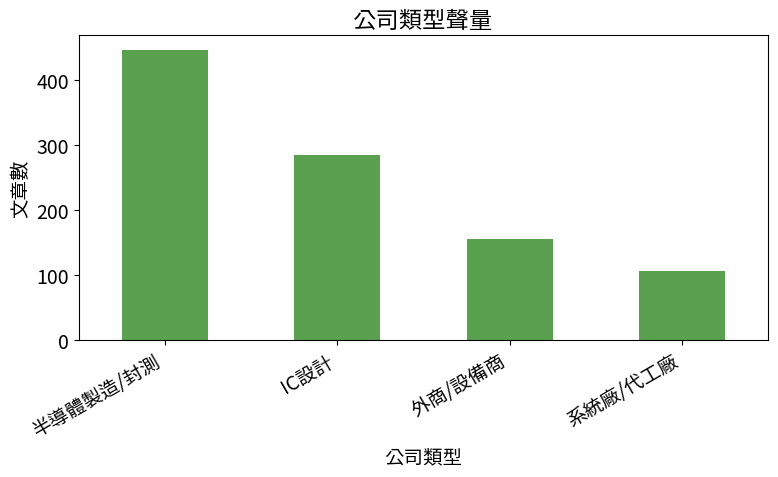

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
group_voice.plot.bar(x='company_group', y='article_count', ax=ax, color='#59A14F', legend=False)
ax.set_title('公司類型聲量')
ax.set_xlabel('公司類型')
ax.set_ylabel('文章數')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

## 5. 文字前處理

說明：設定 jieba 字典、加入自訂詞，並建立模型用停用詞表。


In [ ]:
import os

print(os.getcwd())
print(os.path.exists('./dict/dict.txt.big'))
print(os.listdir('./dict') if os.path.exists('./dict') else 'dict folder not found')

/content/drive/MyDrive/01_NSYSU/02_2026-spring/SMA/project1/final_proj
True
['dict.txt.big', 'stop_words.txt']


In [ ]:
# 設定繁體中文詞庫
jieba.set_dictionary('./dict/dict.txt.big')

# 將公司名稱、別名與議題詞加入 jieba，降低被切碎的機率
custom_words = []
for words in company_keywords.values():
    custom_words.extend(words)
for words in issue_topic_keywords.values():
    custom_words.extend(words)
for w in set(custom_words):
    jieba.add_word(w)
    jieba.add_word(str(w).lower())

with open('./dict/stop_words.txt', encoding='utf-8') as f:
    stopWords = set(line.strip() for line in f.readlines())

company_stopwords = set()
for words in company_keywords.values():
    company_stopwords.update(w.lower() for w in words)

ptt_noise_stopwords = {
    '新聞', '討論', '請益', '心得', '徵才', '問題', '原文', '標題', '日期', '來源', '內文',
    '公司', '科技', '表示', '指出', '報導', '記者', '目前', '今年', '去年', '未來', '相關',
    '一個', '一間', '有人', '請問', '是不是', '覺得', '知道', '大家', '自己', '真的',
    '現在', '可能', '因為', '所以', '如果', '但是', '沒有', '已經', '可以', '這個', '那個',
    '以及', '包括', '進行', '提供', '成為', '需要', '看到', '感覺', '比較', '還是', '時候',
    'sent', 'from', 'jptt', 'pixel', 'pro', 'android', 'iphone', 'on', 'my', '一下', '一些',
}

model_stopwords = stopWords | company_stopwords | ptt_noise_stopwords

Building prefix dict from /content/drive/MyDrive/01_NSYSU/02_2026-spring/SMA/project1/final_proj/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/01_NSYSU/02_2026-spring/SMA/project1/final_proj/dict/dict.txt.big ...
Loading model from cache /tmp/jieba.ud2145e6cdda90752a4a3bb3954b1cd90.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.ud2145e6cdda90752a4a3bb3954b1cd90.cache
Loading model cost 1.514 seconds.
DEBUG:jieba:Loading model cost 1.514 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


說明：定義文字清理與斷詞流程，產生主題模型使用的處理後文本。


In [ ]:
def clean_text(text):
    text = strip_ptt_noise_for_matching(text)
    text = re.sub(r'\[.*?\]', ' ', text)
    text = re.sub(r'^[Rr]e:|^[Ff]w:', ' ', text)
    text = re.sub(r'[^\u4e00-\u9fa5A-Za-z0-9\s]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text


def getToken(row):
    row = clean_text(row)
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w.strip().lower() for w in seg_list
        if w.strip()
        and w.strip().lower() not in model_stopwords
        and len(w.strip()) > 1
        and not w.strip().isdigit()
    ]
    return seg_list

company_df['model_text'] = company_df['analysis_text'].apply(clean_text)
company_df['words'] = company_df['analysis_text'].apply(getToken)
company_df['processed_text'] = company_df['words'].map(' '.join)
company_df[['artTitle', 'companies', 'processed_text']].head()

,artTitle,companies,processed_text
1,[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,[鴻海],事業 軟體 工程師 印度 班加羅爾 事業 印度 班加羅爾 招募 軟體 工程師 一位 大學畢業...
2,Re:[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,[鴻海],事業 軟體 工程師 印度 班加羅爾 陣子 大陸 獵頭 scm 總監 開出 薪水 台幣 萬元
3,[新聞]台積電擴廠外移和供電不穩有關？國科會認了：有影響,[台積電],擴廠 外移 供電 國科會 認了 影響 新聞標題 擴廠 外移 供電 國科會 認了 影響 中時 ...
4,[新聞]蔣尚義：遺憾沒打敗英特爾，台積電未來10,"[台積電, 鴻海]",尚義 遺憾 打敗 英特爾 尚義 遺憾 打敗 英特爾 董事 ky 董事長 尚義 今天 成熟 製...
5,[新聞]亞馬遜執行長賈西開第一槍示警AI導致,[廣達],亞馬遜 執行長 賈西開 第一槍 示警 ai 導致 亞馬遜 執行長 賈西開 第一槍 示警 ai...


說明：檢查每篇文章斷詞後的詞數分布，確認文本長度足以建模。


In [ ]:
company_df['words'].map(len).describe()

,words
count,666.000000
mean,224.412913
std,189.132565
min,8.000000
25%,92.000000
50%,199.000000
75%,281.750000
max,1540.000000


## 6. GuidedLDA：以職場議題作為 seed 的半監督主題模型

- 原始套件: <https://github.com/vi3k6i5/GuidedLDA>  
- 31lab 家銘修改版本: <https://github.com/Text-Analytics-and-Retrieval/GuidedLDA>

安裝方式：  
`pip install git+https://github.com/Text-Analytics-and-Retrieval/GuidedLDA.git#egg=GuidedLDA`

### 6.1 建立 GuidedLDA 需要的 Dictionary 與 Corpus

這裡只建立 GuidedLDA 會用到的詞典與 BOW corpus。

說明：將斷詞結果轉成 GuidedLDA 需要的文件列表。


In [ ]:
docs = company_df['words'].to_list()
docs[0]

['事業',
 '軟體',
 '工程師',
 '印度',
 '班加羅爾',
 '事業',
 '印度',
 '班加羅爾',
 '招募',
 '軟體',
 '工程師',
 '一位',
 '大學畢業',
 '三年',
 '工作',
 '經驗',
 '多益',
 '碩士',
 '畢業',
 '兩年',
 '工作',
 '經驗',
 '多益',
 '自動化',
 '設備',
 'or',
 '測試',
 '設備',
 'or',
 '硬體',
 '開發',
 '軟體',
 '經驗',
 '工作',
 '內容',
 '派駐',
 '印度',
 '一年',
 '測試',
 '組裝',
 '設備',
 '軟體',
 '維護',
 '開發',
 '跨部門',
 '專案',
 '溝通',
 '自動化',
 '工具',
 '系統',
 '工具',
 '開發',
 '維護',
 '職位',
 '工程師',
 'dri',
 '薪資',
 '年資',
 '經歷',
 '計算',
 '包含',
 '派駐',
 '津貼',
 '工作',
 '年度',
 '上半年',
 '下半年',
 '一年',
 '分紅',
 '績效獎金',
 '保障',
 '月薪',
 '印度',
 '每日',
 '美元',
 '稅後',
 '津貼',
 '意者',
 '直接',
 '投遞',
 '履歷']

說明：建立 gensim 字典並過濾過少或過常出現的詞。


In [ ]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=3, no_above=0.8)
print(dictionary)

Dictionary<6084 unique tokens: ['or', '一位', '一年', '三年', '上半年']...>


說明：將每篇文章轉成 BOW corpus，作為 GuidedLDA 輸入。


In [ ]:
# 建立 Bag-of-words 作為文章的特徵表示
# GuidedLDA input 需要將文章轉換成 bag of words，再轉成 DTM
corpus = [dictionary.doc2bow(doc) for doc in docs]

說明：載入 GuidedLDA 套件，準備進行半監督主題模型。


In [ ]:
import guidedlda

說明：將 seed words 對應到字典中的詞彙 id。


In [ ]:
word2id = dictionary.token2id
seed_topic_list = [issue_topic_keywords[name] for name in issue_topic_names]
seed_topic_list

[['薪水',
  '薪資',
  '年薪',
  '分紅',
  '獎金',
  '加薪',
  '調薪',
  'package',
  'bonus',
  '待遇',
  '股票',
  '萬元',
  '億元',
  '月薪',
  '營收',
  '獲利',
  '平均',
  '中位數'],
 ['工時',
  '加班',
  '輪班',
  '值班',
  '責任制',
  '壓力',
  'WLB',
  '下班',
  '生活',
  '爆肝',
  '裁員',
  '員工',
  '人力',
  '組織',
  '管理',
  '機密',
  '調查',
  '違規',
  '要求'],
 ['offer',
  '面試',
  '請益',
  '錄取',
  '履歷',
  '面試官',
  '職缺',
  '徵才',
  '面試流程',
  '選擇',
  '轉職',
  '跳槽',
  '升遷',
  '年資',
  '新人',
  '職涯',
  '離職',
  '工作',
  '主管',
  '經驗'],
 ['製程',
  '設備',
  'IC設計',
  '韌體',
  '軟體',
  'PM',
  'FAE',
  '演算法',
  '研發',
  '工程師',
  '製造',
  '先進製程',
  '先進封裝',
  '廠務',
  '工安',
  '事故',
  '廠區',
  '安全'],
 ['晶片',
  '半導體',
  'AI',
  '人工智慧',
  '美國',
  '中國',
  '輝達',
  '英特爾',
  '投資',
  '關稅',
  '出口管制',
  '供應鏈',
  '產能',
  '擴廠',
  '市場',
  '全球',
  '韓國']]

說明：整理各主題 seed words 是否存在於字典中，確認 GuidedLDA 可使用的提示詞。


In [ ]:
seed_topics = {}
seed_word_status = []

for t_id, st in enumerate(seed_topic_list):
    topic_name = issue_topic_names[t_id]
    for word in st:
        w = word.lower()
        if w in word2id:
            seed_topics[word2id[w]] = t_id
            seed_word_status.append((topic_name, w, 'in_dictionary'))
        else:
            seed_word_status.append((topic_name, w, 'not_found'))

seed_word_status_df = pd.DataFrame(seed_word_status, columns=['topic_name', 'seed_word', 'status'])
seed_word_status_df.groupby(['topic_name', 'status']).size().unstack(fill_value=0)

status,in_dictionary,not_found
topic_name,,
國際產業新聞,16,1
求職面試與職涯,17,3
產業技術與職務,17,1
組織管理與員工議題,16,3
薪資與財務表現,17,1


說明：把 BOW corpus 轉成 GuidedLDA 需要的文件詞矩陣。


In [ ]:
# guidedlda 需要 DTM 格式作為 input，因此這邊利用 corpus2dense() 方法進行轉換
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

說明：依 seed topic 數量訓練 GuidedLDA 模型。


In [ ]:
guided_topic_num = len(seed_topic_list)

guided_model = guidedlda.GuidedLDA(n_topics=guided_topic_num, n_iter=100, random_state=7, refresh=20)
guided_model.fit(X, seed_topics=seed_topics, seed_confidence=0.8)

說明：輸出每個 GuidedLDA 主題的代表詞，供後續人工命名與解釋。


In [ ]:
# 整理／顯示主題模型結果
n_top_words = 12
topic_word = guided_model.topic_word_
vocab = tuple(dictionary.token2id.keys())

guided_topic_words = []
for i, topic_dist in enumerate(topic_word):
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    guided_topic_words.append({
        'guidedlda_topic': i + 1,
        'seed_topic_name': issue_topic_names[i],
        'top_words': ' '.join(topic_words),
    })
    print('Topic {} [{}]: {}'.format(i + 1, issue_topic_names[i], ' '.join(topic_words)))

guided_topic_words_df = pd.DataFrame(guided_topic_words)
guided_topic_words_df

Topic 1 [薪資與財務表現]: 台灣 員工 產業 億元 需求 全球 萬元 市府 台北 營收 高雄 人才
Topic 2 [組織管理與員工議題]: 員工 資料 工程師 機密 技術 唯仁 認為 管理 調查 國家 東京 gemini
Topic 3 [求職面試與職涯]: 工作 工程師 面試 主管 台灣 時間 美國 薪資 應該 內容 offer 經驗
Topic 4 [產業技術與職務]: 英特爾 製程 奈米 客戶 三星 技術 產能 晶圓 代工 設備 製造 生產
Topic 5 [國際產業新聞]: ai 晶片 美國 台灣 中國 半導體 投資 全球 企業 產業 億美元 市場


,guidedlda_topic,seed_topic_name,top_words
0,1,薪資與財務表現,台灣 員工 產業 億元 需求 全球 萬元 市府 台北 營收 高雄 人才
1,2,組織管理與員工議題,員工 資料 工程師 機密 技術 唯仁 認為 管理 調查 國家 東京 gemini
2,3,求職面試與職涯,工作 工程師 面試 主管 台灣 時間 美國 薪資 應該 內容 offer 經驗
3,4,產業技術與職務,英特爾 製程 奈米 客戶 三星 技術 產能 晶圓 代工 設備 製造 生產
4,5,國際產業新聞,ai 晶片 美國 台灣 中國 半導體 投資 全球 企業 產業 億美元 市場


#### 結果解讀：GuidedLDA 主題
GuidedLDA 產生的五個主題大致可解釋為：薪資與財務表現、組織管理與員工議題、求職面試與職涯、產業技術與職務、國際產業新聞。其中「國際產業新聞」仍是最大主題，符合資料集中大量新聞與 AI/半導體產業討論的特性。

說明：整理 GuidedLDA 的文件主題分布，並建立 pyLDAvis 視覺化物件。


In [ ]:
doc_topic = guided_model.doc_topic_ # 文件-主題 分佈
term_freq = [dictionary.cfs[i] for i in range(len(dictionary))] # 每個詞在整個語料中出現的總次數，依 token id 排列
doc_len = [sum(v for k, v in doc) for doc in corpus] # 每篇文章的長度

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab=vocab, term_frequency=term_freq)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.085084 -0.031024       1        1  40.539848
3     -0.123670 -0.174758       2        1  16.969968
2     -0.277554 -0.016835       3        1  15.521769
0      0.280347 -0.129268       4        1  15.063654
1      0.035793  0.351885       5        1  11.904761, topic_info=    Term         Freq        Total Category  logprob  loglift
293   ai  2074.000000  2074.000000  Default  30.0000  30.0000
249  英特爾   503.000000   503.000000  Default  29.0000  29.0000
254   製程   397.000000   397.000000  Default  28.0000  28.0000
219   晶片  1238.000000  1238.000000  Default  27.0000  27.0000
17    工作   423.000000   423.000000  Default  26.0000  26.0000
..   ...          ...          ...      ...      ...      ...
652   是否    61.762565   134.664809   Topic5  -5.4650   1.3487
238   研發    68.734633   214.338581   Topic5  -5.3580   0.9909
847   團隊    58.774535   129.602052   Topic5  -5.5145   1.3375
309   內部    54.790496   117.712219   Topic5  -5.5847   1.3635
64    企業    56.782516   484.080768   Topic5  -5.5490  -0.0148

[316 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
3678      2  1.001707   18a
3886      2  1.001759    5y
293       1  0.967112    ai
293       3  0.032783    ai
1564      2  1.001759  asic
...     ...       ...   ...
530       2  1.001870    高通
1302      4  1.001652    高鐵
432       4  1.002789    高雄
2891      3  0.034283   魏哲家
2891      4  0.968507   魏哲家

[428 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 1, 2])

說明：將 GuidedLDA 的互動式視覺化結果輸出成 HTML 檔。


In [ ]:
pyLDAvis.save_html(p, './guidedlda_company_issue.html')

說明：將每篇文章分配到機率最高的 GuidedLDA 主題。


In [ ]:
company_df['guidedlda_topic_id'] = doc_topic.argmax(axis=1) + 1
company_df['guidedlda_issue_name'] = company_df['guidedlda_topic_id'].map(
    dict(enumerate(issue_topic_names, start=1))
)
company_df['guidedlda_issue_name'].value_counts()

,count
guidedlda_issue_name,
國際產業新聞,249
求職面試與職涯,157
薪資與財務表現,100
產業技術與職務,81
組織管理與員工議題,79


## 7. GuidedLDA 的公司 × 主題分析

比較不同公司常被模型分到哪些職場／產業議題。

說明：展開公司標籤並合併 GuidedLDA 主題，建立公司 × 主題分析資料。


In [ ]:
company_topic_df = company_df.explode('companies').rename(columns={'companies': 'company'}).copy()
company_topic_df['company_group'] = company_topic_df['company'].map(company_group_map)
company_topic_df[['artTitle', 'company', 'company_group', 'guidedlda_issue_name']].head(10)

,artTitle,company,company_group,guidedlda_issue_name
1,[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,鴻海,系統廠/代工廠,求職面試與職涯
2,Re:[徵才]鴻海A事業群-軟體工程師-印度班加羅爾,鴻海,系統廠/代工廠,求職面試與職涯
3,[新聞]台積電擴廠外移和供電不穩有關？國科會認了：有影響,台積電,半導體製造/封測,薪資與財務表現
4,[新聞]蔣尚義：遺憾沒打敗英特爾，台積電未來10,台積電,半導體製造/封測,國際產業新聞
4,[新聞]蔣尚義：遺憾沒打敗英特爾，台積電未來10,鴻海,系統廠/代工廠,國際產業新聞
5,[新聞]亞馬遜執行長賈西開第一槍示警AI導致,廣達,系統廠/代工廠,國際產業新聞
6,[討論]南部是不是把主要產業全部押寶上台積了,台積電,半導體製造/封測,薪資與財務表現
6,[討論]南部是不是把主要產業全部押寶上台積了,聯發科,IC設計,薪資與財務表現
6,[討論]南部是不是把主要產業全部押寶上台積了,群聯,IC設計,薪資與財務表現
6,[討論]南部是不是把主要產業全部押寶上台積了,鴻海,系統廠/代工廠,薪資與財務表現


說明：計算各公司在不同 GuidedLDA 主題上的比例分布。


In [ ]:
company_guided_topic_count = pd.crosstab(
    company_topic_df['company'],
    company_topic_df['guidedlda_issue_name']
).reindex(columns=issue_topic_names, fill_value=0)

company_guided_topic_table = pd.crosstab(
    company_topic_df['company'],
    company_topic_df['guidedlda_issue_name'],
    normalize='index'
).reindex(columns=issue_topic_names, fill_value=0).fillna(0)

company_guided_topic_table

guidedlda_issue_name,薪資與財務表現,組織管理與員工議題,求職面試與職涯,產業技術與職務,國際產業新聞
company,,,,,
AMD,0.093023,0.000000,0.069767,0.093023,0.744186
ASML,0.086957,0.000000,0.217391,0.173913,0.521739
Google,0.021277,0.106383,0.287234,0.042553,0.542553
NVIDIA,0.128834,0.024540,0.049080,0.085890,0.711656
世界先進,0.250000,0.000000,0.500000,0.000000,0.250000
仁寶,0.333333,0.000000,0.333333,0.000000,0.333333
友達,0.200000,0.200000,0.400000,0.000000,0.200000
台積電,0.154028,0.154028,0.196682,0.137441,0.357820
和碩,0.181818,0.000000,0.454545,0.000000,0.363636


說明：定義熱力圖函數，用來呈現公司與主題比例。


In [ ]:
def plot_heatmap(table, title, figsize=(12, 8), percent=True):
    plot_data = table.copy()
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(plot_data.values, aspect='auto', cmap='YlGnBu')
    ax.set_xticks(np.arange(plot_data.shape[1]))
    ax.set_yticks(np.arange(plot_data.shape[0]))
    ax.set_xticklabels(plot_data.columns)
    ax.set_yticklabels(plot_data.index)
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
    ax.set_title(title)

    for i in range(plot_data.shape[0]):
        for j in range(plot_data.shape[1]):
            value = plot_data.iloc[i, j]
            label = f'{value:.0%}' if percent else f'{value:.0f}'
            ax.text(j, i, label, ha='center', va='center', fontsize=9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('比例' if percent else '文章數', rotation=-90, va='bottom')
    plt.tight_layout()
    return ax

說明：篩選文章數足夠的公司，繪製公司 × GuidedLDA 主題熱力圖。


<Axes: title={'center': '公司 × GuidedLDA 主題比例'}>

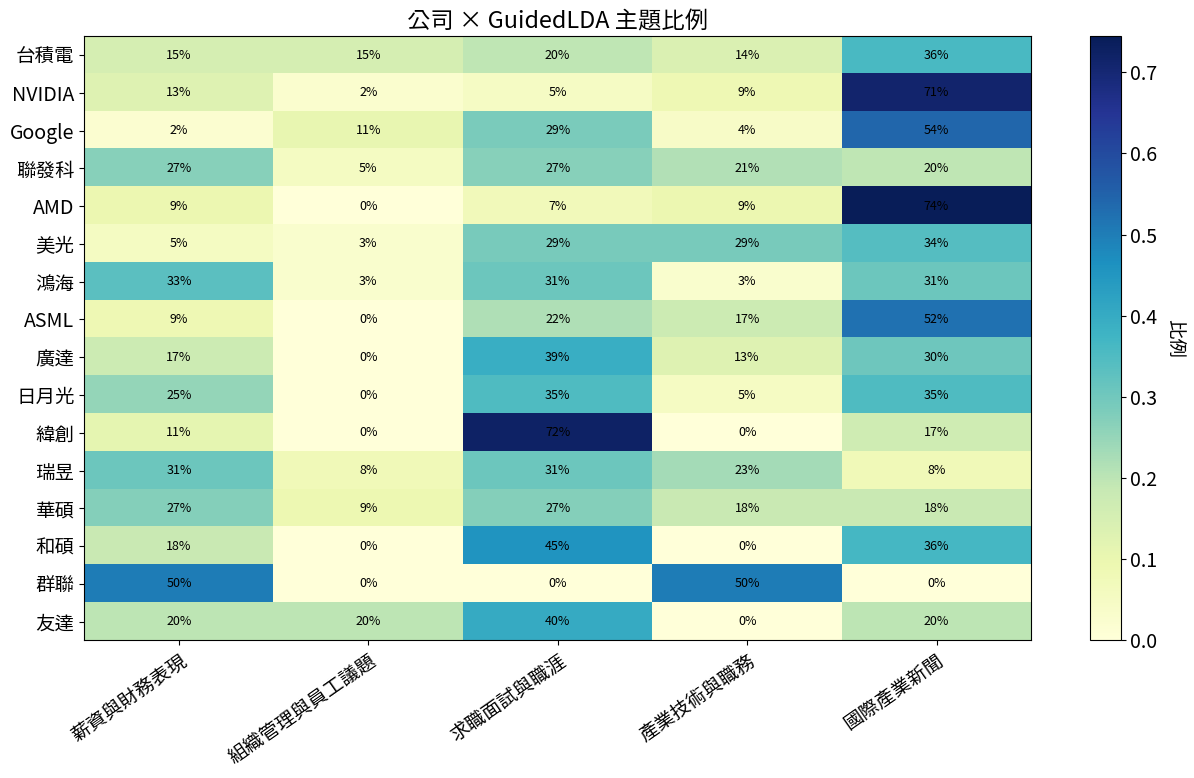

In [ ]:
min_company_articles = 5
display_companies = company_voice.loc[
    company_voice['article_count'] >= min_company_articles,
    'company'
].tolist()

plot_heatmap(
    company_guided_topic_table.loc[display_companies],
    '公司 × GuidedLDA 主題比例',
    figsize=(13, max(5, len(display_companies) * 0.5)),
    percent=True,
)

說明：計算公司類型 × GuidedLDA 主題比例，觀察不同產業類型的議題差異。


In [ ]:
group_guided_topic_table = pd.crosstab(
    company_topic_df['company_group'],
    company_topic_df['guidedlda_issue_name'],
    normalize='index'
).reindex(columns=issue_topic_names, fill_value=0).fillna(0)

group_guided_topic_table

guidedlda_issue_name,薪資與財務表現,組織管理與員工議題,求職面試與職涯,產業技術與職務,國際產業新聞
company_group,,,,,
IC設計,0.171930,0.028070,0.108772,0.126316,0.564912
半導體製造/封測,0.159193,0.145740,0.206278,0.132287,0.356502
外商/設備商,0.038710,0.070968,0.277419,0.122581,0.490323
系統廠/代工廠,0.233645,0.028037,0.411215,0.056075,0.271028


#### 結果解讀：公司類型 × GuidedLDA 主題
公司類型比較顯示，IC 設計與外商/設備商較集中在國際產業新聞；系統廠/代工廠在求職面試與薪資財務議題上的比例較高；半導體製造/封測則分布較平均，兼具產業新聞、求職職涯、組織管理與技術職務議題。這張表最適合用來回答不同公司類型的討論形象差異。

說明：繪製公司類型 × GuidedLDA 主題熱力圖。


<Axes: title={'center': '公司類型 × GuidedLDA 主題比例'}>

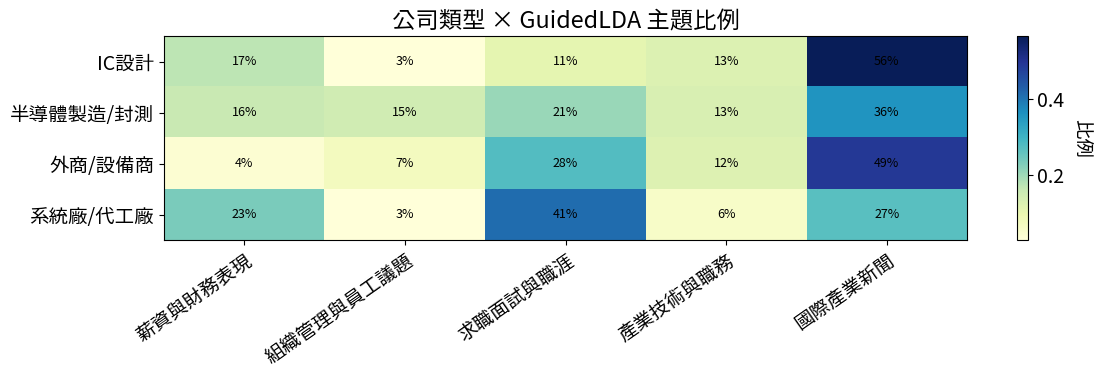

In [ ]:
plot_heatmap(
    group_guided_topic_table,
    '公司類型 × GuidedLDA 主題比例',
    figsize=(12, 4),
    percent=True,
)

## 8. 最後結論
本研究以 PTT Tech_Job 中與科技公司相關的文章作為分析資料。原始資料共有 686 篇，其中 666 篇可標記到至少一個公司名稱，顯示資料集大多符合本研究「科技公司品牌聲量與職場形象」的分析目標。

在公司聲量方面，討論明顯集中於台積電，共 422 篇；其次為 NVIDIA 163 篇、Google 94 篇、聯發科 56 篇與 AMD 43 篇。若依公司類型觀察，半導體製造/封測有 446 筆公司標記，IC 設計有 285 筆，外商/設備商有 155 筆，系統廠/代工廠有 107 筆。這表示 Tech_Job 中的公司討論主要集中在半導體與 AI 供應鏈相關企業。

GuidedLDA 的結果顯示，最大主題為「國際產業新聞」249 篇，其次是「求職面試與職涯」157 篇、「薪資與財務表現」100 篇、「產業技術與職務」81 篇，以及「組織管理與員工議題」79 篇。這代表本資料中的公司討論不只是職缺或薪資問題，也受到 AI、晶片、半導體產業競爭與國際投資新聞高度影響。

從公司類型與主題分布來看，IC 設計與外商/設備商較常連結到國際產業新聞；系統廠/代工廠較常連結到求職面試與薪資財務議題；半導體製造/封測則分布較平均，同時涵蓋產業新聞、求職職涯、組織管理與技術職務。這說明不同公司類型在 PTT Tech_Job 中呈現出的討論形象有所差異。